In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision
from PIL import Image
import json
import os
import numpy as np
from tqdm import tqdm
import cv2


In [ ]:

# Dataset Configuration
DATASET_PATH = "/content/drive/MyDrive/final_augmentation/coco shear"
ANNOTATIONS_PATH = os.path.join(DATASET_PATH, "annotations")
MODEL_SAVE_PATH = "/content/drive/MyDrive/coco_saves"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"✓ Dataset path: {DATASET_PATH}")
print(f"✓ Annotations path: {ANNOTATIONS_PATH}")
print(f"✓ Models will be saved to: {MODEL_SAVE_PATH}")


✓ Dataset path: /content/drive/MyDrive/final_augmentation/coco shear
✓ Annotations path: /content/drive/MyDrive/final_augmentation/coco shear/annotations
✓ Models will be saved to: /content/drive/MyDrive/coco_saves


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision
from PIL import Image
import json
import os
import numpy as np
from tqdm import tqdm
import cv2

# Hyperparameters
IMG_SIZE = 416
BATCH_SIZE = 22
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
NUM_CLASSES = 1  # Potholes
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Anchor boxes for different scales (width, height) normalized
ANCHORS = [
    [(0.1, 0.1), (0.2, 0.15), (0.15, 0.2)],  # Small objects - 52x52
    [(0.3, 0.3), (0.4, 0.25), (0.25, 0.4)],  # Medium objects - 26x26
    [(0.5, 0.5), (0.6, 0.45), (0.45, 0.6)]   # Large objects - 13x13
]

# ==================== CSPDarknet Backbone Components ====================

class ConvBlock(nn.Module):
    """Basic Conv-BN-LeakyReLU block"""
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualBlock(nn.Module):
    """Residual block used in Darknet"""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvBlock(channels, channels // 2, 1, 1, 0)
        self.conv2 = ConvBlock(channels // 2, channels, 3, 1, 1)

    def forward(self, x):
        return x + self.conv2(self.conv1(x))

class CSPBlock(nn.Module):
    """Cross Stage Partial block"""
    def __init__(self, in_ch, out_ch, num_blocks):
        super().__init__()
        self.conv1 = ConvBlock(in_ch, out_ch // 2, 1, 1, 0)
        self.conv2 = ConvBlock(in_ch, out_ch // 2, 1, 1, 0)
        self.residual_blocks = nn.Sequential(
            *[ResidualBlock(out_ch // 2) for _ in range(num_blocks)]
        )
        self.conv3 = ConvBlock(out_ch // 2, out_ch // 2, 1, 1, 0)
        self.conv4 = ConvBlock(out_ch, out_ch, 1, 1, 0)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x1 = self.residual_blocks(x1)
        x1 = self.conv3(x1)
        x = torch.cat([x1, x2], dim=1)
        return self.conv4(x)

class CSPDarknet53(nn.Module):
    """CSPDarknet53 Backbone (YOLO-style)"""
    def __init__(self):
        super().__init__()
        # Stem
        self.stem = ConvBlock(3, 32, 3, 1, 1)

        # Downsampling + CSP blocks
        self.stage1 = nn.Sequential(
            ConvBlock(32, 64, 3, 2, 1),
            CSPBlock(64, 64, 1)
        )

        self.stage2 = nn.Sequential(
            ConvBlock(64, 128, 3, 2, 1),
            CSPBlock(128, 128, 2)
        )

        self.stage3 = nn.Sequential(
            ConvBlock(128, 256, 3, 2, 1),
            CSPBlock(256, 256, 8)
        )

        self.stage4 = nn.Sequential(
            ConvBlock(256, 512, 3, 2, 1),
            CSPBlock(512, 512, 8)
        )

        self.stage5 = nn.Sequential(
            ConvBlock(512, 1024, 3, 2, 1),
            CSPBlock(1024, 1024, 4)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)

        # Extract multi-scale features
        c3 = self.stage3(x)  # 52x52
        c4 = self.stage4(c3)  # 26x26
        c5 = self.stage5(c4)  # 13x13

        return c3, c4, c5

# ==================== SSD Detection Head Components ====================

class SSDDetectionHead(nn.Module):
    """SSD-style detection head for a single scale"""
    def __init__(self, in_channels, num_anchors, num_classes):
        super().__init__()
        # Location prediction (4 values: dx, dy, dw, dh per anchor)
        self.loc_conv = nn.Conv2d(in_channels, num_anchors * 4, 3, 1, 1)

        # Class prediction (num_classes + 1 for background)
        self.cls_conv = nn.Conv2d(in_channels, num_anchors * (num_classes + 1), 3, 1, 1)

        # Confidence prediction
        self.conf_conv = nn.Conv2d(in_channels, num_anchors, 3, 1, 1)

        self.num_anchors = num_anchors
        self.num_classes = num_classes

    def forward(self, x):
        batch_size = x.size(0)

        # Location predictions
        loc = self.loc_conv(x)
        loc = loc.permute(0, 2, 3, 1).contiguous()
        loc = loc.view(batch_size, -1, 4)

        # Class predictions
        cls = self.cls_conv(x)
        cls = cls.permute(0, 2, 3, 1).contiguous()
        cls = cls.view(batch_size, -1, self.num_classes + 1)

        # Confidence predictions
        conf = self.conf_conv(x)
        conf = conf.permute(0, 2, 3, 1).contiguous()
        conf = conf.view(batch_size, -1, 1)

        return loc, cls, conf

# ==================== Complete Hybrid Model ====================

class YOLOSSDHybrid(nn.Module):
    """YOLO Backbone + SSD Head Hybrid Model"""
    def __init__(self, num_classes=1):
        super().__init__()
        self.num_classes = num_classes
        self.backbone = CSPDarknet53()

        # Detection heads for each scale
        self.head_small = SSDDetectionHead(256, len(ANCHORS[0]), num_classes)  # 52x52
        self.head_medium = SSDDetectionHead(512, len(ANCHORS[1]), num_classes)  # 26x26
        self.head_large = SSDDetectionHead(1024, len(ANCHORS[2]), num_classes)  # 13x13

    def forward(self, x):
        # Extract multi-scale features
        c3, c4, c5 = self.backbone(x)

        # Apply detection heads
        loc_small, cls_small, conf_small = self.head_small(c3)
        loc_medium, cls_medium, conf_medium = self.head_medium(c4)
        loc_large, cls_large, conf_large = self.head_large(c5)

        # Concatenate predictions from all scales
        loc = torch.cat([loc_small, loc_medium, loc_large], dim=1)
        cls = torch.cat([cls_small, cls_medium, cls_large], dim=1)
        conf = torch.cat([conf_small, conf_medium, conf_large], dim=1)

        return loc, cls, conf

# ==================== Dataset ====================

class PotholeDataset(Dataset):
    """COCO format pothole dataset"""
    def __init__(self, root_dir, annotation_file, transform=None, img_size=416):
        self.root_dir = root_dir
        self.transform = transform
        self.img_size = img_size

        # Load COCO annotations
        with open(annotation_file, 'r') as f:
            self.coco_data = json.load(f)

        self.images = self.coco_data['images']
        self.annotations = self.coco_data['annotations']

        # Create image_id to annotations mapping
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        # Load image
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size

        # Get annotations for this image
        img_id = img_info['id']
        anns = self.img_to_anns.get(img_id, [])

        # Process bounding boxes
        boxes = []
        labels = []
        for ann in anns:
            bbox = ann['bbox']  # [x, y, width, height]
            x, y, w, h = bbox

            # Normalize to [0, 1]
            x_center = (x + w / 2) / orig_w
            y_center = (y + h / 2) / orig_h
            w_norm = w / orig_w
            h_norm = h / orig_h

            boxes.append([x_center, y_center, w_norm, h_norm])
            labels.append(0)  # Pothole class = 0

        # Transform image
        if self.transform:
            image = self.transform(image)

        # Convert to tensors
        if len(boxes) > 0:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.long)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)

        return image, boxes, labels

# ==================== Loss Function ====================

class HybridLoss(nn.Module):
    """Combined loss for YOLO-SSD hybrid with IoU matching"""
    def __init__(self, num_classes=1, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.num_classes = num_classes
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='none')
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')
        self.mse_loss = nn.MSELoss(reduction='none')

        # Anchor configuration matching the model output concatenation order
        # Output order: Small (52x52), Medium (26x26), Large (13x13)
        self.grids = [52, 26, 13]
        self.anchors_config = ANCHORS

    def generate_dense_anchors(self, device):
        """Generate dense anchor boxes for all scales"""
        all_anchors = []
        for i, grid_size in enumerate(self.grids):
            # Create grid
            y, x = torch.meshgrid(torch.arange(grid_size, device=device), torch.arange(grid_size, device=device), indexing='ij')

            # Center of grid cells normalized [0,1]
            x = (x + 0.5) / grid_size
            y = (y + 0.5) / grid_size

            # Expand for number of anchors per scale
            num_anchors = len(self.anchors_config[i])
            x = x.unsqueeze(-1).repeat(1, 1, num_anchors)
            y = y.unsqueeze(-1).repeat(1, 1, num_anchors)

            # Widths and heights
            wh = torch.tensor(self.anchors_config[i], device=device).float()
            w = wh[:, 0].view(1, 1, num_anchors).repeat(grid_size, grid_size, 1)
            h = wh[:, 1].view(1, 1, num_anchors).repeat(grid_size, grid_size, 1)

            # Stack to get [Grid, Grid, NumAnchors, 4] then flatten to [N, 4]
            grid_anchors = torch.stack([x, y, w, h], dim=-1).view(-1, 4)
            all_anchors.append(grid_anchors)

        return torch.cat(all_anchors, dim=0) # [TotalAnchors, 4]

    def xywh_to_xyxy(self, boxes):
        """Convert [cx, cy, w, h] to [x1, y1, x2, y2]"""
        x1 = boxes[:, 0] - boxes[:, 2] / 2
        y1 = boxes[:, 1] - boxes[:, 3] / 2
        x2 = boxes[:, 0] + boxes[:, 2] / 2
        y2 = boxes[:, 1] + boxes[:, 3] / 2
        return torch.stack([x1, y1, x2, y2], dim=1)

    def box_iou(self, boxes1, boxes2):
        """
        Compute IoU between two sets of boxes.
        boxes1: [N, 4]
        boxes2: [M, 4]
        Returns: [N, M]
        """
        area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
        area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

        lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
        rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])

        wh = (rb - lt).clamp(min=0)
        inter = wh[:, :, 0] * wh[:, :, 1]

        union = area1[:, None] + area2 - inter
        return inter / (union + 1e-6)

    def forward(self, predictions, targets, anchors=None):
        loc_pred, cls_pred, conf_pred = predictions
        batch_size = loc_pred.size(0)
        device = loc_pred.device

        # Generate anchors dynamically on the correct device
        dense_anchors = self.generate_dense_anchors(device)

        loss_loc = 0.0
        loss_cls = 0.0
        loss_conf = 0.0

        for b in range(batch_size):
            t_boxes, t_labels = targets[b]
            p_conf = conf_pred[b] # [N, 1]
            p_loc = loc_pred[b]   # [N, 4]
            p_cls = cls_pred[b]   # [N, C+1]

            if len(t_boxes) == 0:
                # No objects: penalize confidence for all anchors (Negative Mining or Weighted)
                conf_loss_all = self.bce_loss(p_conf, torch.zeros_like(p_conf))
                loss_conf += conf_loss_all.sum() * self.lambda_noobj
                continue

            t_boxes = t_boxes.to(device)
            t_labels = t_labels.to(device)

            # Convert to XYXY for IoU calculation
            anchors_xyxy = self.xywh_to_xyxy(dense_anchors)
            t_boxes_xyxy = self.xywh_to_xyxy(t_boxes)

            # Calculate IoU [N_anchors, N_targets]
            ious = self.box_iou(anchors_xyxy, t_boxes_xyxy)

            # --- Matching Strategy ---
            # 1. Best IoU for each anchor
            best_iou_per_anchor, best_gt_idx = ious.max(dim=1)

            # 2. Thresholding for positive/negative masks
            mask_pos = best_iou_per_anchor > 0.5

            # 3. Ensure each GT has at least one matching anchor (best one)
            best_iou_per_gt, best_anchor_idx = ious.max(dim=0)
            mask_pos[best_anchor_idx] = True

            # Get final GT indices for positive anchors
            assigned_gt_idx = best_gt_idx[mask_pos]

            # --- Localization Loss (Positives) ---
            if mask_pos.sum() > 0:
                pos_gt_boxes = t_boxes[assigned_gt_idx]
                pos_loc_pred = p_loc[mask_pos]
                loss_loc += self.mse_loss(pos_loc_pred, pos_gt_boxes).sum() * self.lambda_coord

                # --- Classification Loss (Positives) ---
                pos_gt_labels = t_labels[assigned_gt_idx]
                pos_cls_pred = p_cls[mask_pos]
                loss_cls += self.ce_loss(pos_cls_pred, pos_gt_labels).sum()

            # --- Confidence Loss (All Anchors) ---
            # Positives: target = 1
            # Negatives: target = 0
            conf_targets = torch.zeros_like(p_conf)
            conf_targets[mask_pos] = 1.0

            conf_losses = self.bce_loss(p_conf, conf_targets)

            # Sum positive losses
            loss_conf += conf_losses[mask_pos].sum()

            # Sum negative losses (weighted)
            loss_conf += conf_losses[~mask_pos].sum() * self.lambda_noobj

        return (loss_loc + loss_cls + loss_conf) / batch_size, loss_loc/batch_size, loss_cls/batch_size, loss_conf/batch_size

# ==================== Training ====================

def train_model():
    # Data transforms
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load dataset
    train_annotation = os.path.join(ANNOTATIONS_PATH, "train.json")
    val_annotation = os.path.join(ANNOTATIONS_PATH, "val.json")

    train_dataset = PotholeDataset(
        root_dir=os.path.join(DATASET_PATH, "train"),
        annotation_file=train_annotation,
        transform=transform,
        img_size=IMG_SIZE
    )

    val_dataset = PotholeDataset(
        root_dir=os.path.join(DATASET_PATH, "val"),
        annotation_file=val_annotation,
        transform=transform,
        img_size=IMG_SIZE
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, collate_fn=lambda x: list(zip(*x)))
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, collate_fn=lambda x: list(zip(*x)))

    # Initialize model
    model = YOLOSSDHybrid(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = HybridLoss(num_classes=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    print(f"\n{'='*60}")
    print(f"Training YOLO-SSD Hybrid Model")
    print(f"{'='*60}")
    print(f"Device: {DEVICE}")
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    print(f"{'='*60}\n")

    best_loss = float('inf')
    train_losses_history = []
    val_losses_history = []

    for epoch in range(NUM_EPOCHS):
        # Training
        model.train()
        train_loss = 0
        train_loc_loss = 0
        train_cls_loss = 0
        train_conf_loss = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        for images, boxes, labels in pbar:
            images = torch.stack(images).to(DEVICE)
            targets = list(zip(boxes, labels))

            optimizer.zero_grad()
            predictions = model(images)

            loss, loc_loss, cls_loss, conf_loss = criterion(predictions, targets, ANCHORS)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_loc_loss += loc_loss.item()
            train_cls_loss += cls_loss.item()
            train_conf_loss += conf_loss.item()

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        scheduler.step()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, boxes, labels in val_loader:
                images = torch.stack(images).to(DEVICE)
                targets = list(zip(boxes, labels))

                predictions = model(images)
                loss, _, _, _ = criterion(predictions, targets, ANCHORS)
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        train_losses_history.append(avg_train_loss)
        val_losses_history.append(avg_val_loss)

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print(f"Train Loss: {avg_train_loss:.4f} (Loc: {train_loc_loss/len(train_loader):.4f}, "
              f"Cls: {train_cls_loss/len(train_loader):.4f}, Conf: {train_conf_loss/len(train_loader):.4f})")
        print(f"Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
            }, os.path.join(MODEL_SAVE_PATH, 'best_hybrid_model.pth'))
            print(f"✓ Best model saved with val loss: {best_loss:.4f}")

        # Save checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_train_loss,
            }, os.path.join(MODEL_SAVE_PATH, f'checkpoint_epoch_{epoch+1}.pth'))

    print("\n" + "="*60)
    print("Training completed!")
    print(f"Best validation loss: {best_loss:.4f}")
    print("="*60)

    # Final evaluation on validation set
    print("\nRunning final evaluation on validation set...")
    model.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_hybrid_model.pth'))['model_state_dict'])
    final_metrics = evaluate_model(model, val_loader, iou_threshold=0.5, conf_threshold=0.5)

    return train_losses_history, val_losses_history

# ==================== Evaluation Metrics ====================

def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two boxes"""
    # box format: [x1, y1, x2, y2]
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    inter_area = max(0, x2_inter - x1_inter) * max(0, y2_inter - y1_inter)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area

def calculate_ap(precisions, recalls):
    """Calculate Average Precision using 11-point interpolation"""
    ap = 0
    for t in np.arange(0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11
    return ap

def calculate_metrics(predictions, ground_truths, iou_threshold=0.5, conf_threshold=0.5):
    """
    Calculate precision, recall, F1, and AP
    predictions: list of dicts with 'bbox', 'score', 'class'
    ground_truths: list of dicts with 'bbox', 'class'
    """
    # Filter predictions by confidence
    predictions = [p for p in predictions if p['score'] >= conf_threshold]

    # Sort predictions by confidence (descending)
    predictions = sorted(predictions, key=lambda x: x['score'], reverse=True)

    tp = 0  # True positives
    fp = 0  # False positives
    fn = len(ground_truths)  # False negatives (all ground truths initially)

    matched_gts = set()

    precision_list = []
    recall_list = []

    for pred in predictions:
        pred_box = pred['bbox']
        best_iou = 0
        best_gt_idx = -1

        # Find best matching ground truth
        for gt_idx, gt in enumerate(ground_truths):
            if gt_idx in matched_gts:
                continue

            gt_box = gt['bbox']
            iou = calculate_iou(pred_box, gt_box)

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        # Check if match is good enough
        if best_iou >= iou_threshold and best_gt_idx != -1:
            tp += 1
            fn -= 1
            matched_gts.add(best_gt_idx)
        else:
            fp += 1

        # Calculate precision and recall at this point
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / len(ground_truths) if len(ground_truths) > 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)

    # Final metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Calculate AP
    if len(precision_list) > 0:
        ap = calculate_ap(np.array(precision_list), np.array(recall_list))
    else:
        ap = 0

    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'ap': ap,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }

def apply_nms(detections, nms_threshold):
    """Apply Non-Maximum Suppression to detections"""
    if len(detections) == 0:
        return []

    # Extract boxes and scores
    boxes = torch.tensor([d['bbox'] for d in detections], dtype=torch.float32)
    scores = torch.tensor([d['score'] for d in detections], dtype=torch.float32)

    # Apply NMS (boxes must be x1, y1, x2, y2)
    keep_indices = torchvision.ops.nms(boxes, scores, nms_threshold)

    return [detections[i] for i in keep_indices]

def evaluate_model(model, dataloader, iou_threshold=0.5, conf_threshold=0.5, nms_threshold=0.45):
    """Evaluate model on entire dataset"""
    model.eval()

    all_predictions = []
    all_ground_truths = []

    print("\nEvaluating model...")
    with torch.no_grad():
        for images, boxes_list, labels_list in tqdm(dataloader, desc="Inference"):
            images = torch.stack(images).to(DEVICE)
            batch_size = images.size(0)

            # Get predictions
            loc_pred, cls_pred, conf_pred = model(images)

            # Post-process predictions
            conf_pred = torch.sigmoid(conf_pred)
            cls_pred = torch.softmax(cls_pred, dim=-1)

            for b in range(batch_size):
                # Filter by confidence
                mask = conf_pred[b].squeeze(-1) > conf_threshold

                if mask.sum() == 0:
                    all_predictions.append([])
                else:
                    boxes = loc_pred[b][mask]
                    scores = conf_pred[b][mask]

                    # Convert to pixel coordinates (assuming image was resized to IMG_SIZE)
                    detections = []
                    for box, score in zip(boxes, scores):
                        x_center, y_center, w, h = box
                        x1 = int((x_center - w/2) * IMG_SIZE)
                        y1 = int((y_center - h/2) * IMG_SIZE)
                        x2 = int((x_center + w/2) * IMG_SIZE)
                        y2 = int((y_center + h/2) * IMG_SIZE)

                        detections.append({
                            'bbox': [x1, y1, x2, y2],
                            'score': score.item(),
                            'class': 'pothole'
                        })

                    # Apply NMS
                    detections = apply_nms(detections, nms_threshold)
                    all_predictions.append(detections)

                # Get ground truths
                gt_boxes = boxes_list[b]
                if len(gt_boxes) > 0:
                    gts = []
                    for box in gt_boxes:
                        x_center, y_center, w, h = box
                        x1 = int((x_center - w/2) * IMG_SIZE)
                        y1 = int((y_center - h/2) * IMG_SIZE)
                        x2 = int((x_center + w/2) * IMG_SIZE)
                        y2 = int((y_center + h/2) * IMG_SIZE)

                        gts.append({
                            'bbox': [x1, y1, x2, y2],
                            'class': 'pothole'
                        })
                    all_ground_truths.append(gts)
                else:
                    all_ground_truths.append([])

    # Calculate metrics for each image and aggregate
    all_metrics = []
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for preds, gts in zip(all_predictions, all_ground_truths):
        if len(gts) > 0:  # Only evaluate images with ground truth
            metrics = calculate_metrics(preds, gts, iou_threshold, conf_threshold)
            all_metrics.append(metrics)
            total_tp += metrics['tp']
            total_fp += metrics['fp']
            total_fn += metrics['fn']

    # Calculate overall metrics
    overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0

    # Calculate mAP@50
    if len(all_metrics) > 0:
        map_50 = np.mean([m['ap'] for m in all_metrics])
    else:
        map_50 = 0

    results = {
        'mAP@50': map_50,
        'precision': overall_precision,
        'recall': overall_recall,
        'f1_score': overall_f1,
        'total_tp': total_tp,
        'total_fp': total_fp,
        'total_fn': total_fn
    }

    return results

# ==================== Inference ====================

def detect_potholes(model, image_path, conf_threshold=0.5, nms_threshold=0.4):
    """Run inference on a single image"""
    model.eval()

    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    orig_w, orig_h = image.size

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        loc_pred, cls_pred, conf_pred = model(image_tensor)

    # Post-process predictions
    conf_pred = torch.sigmoid(conf_pred)
    cls_pred = torch.softmax(cls_pred, dim=-1)

    # Filter by confidence
    mask = conf_pred.squeeze(-1) > conf_threshold

    if mask.sum() == 0:
        return []

    boxes = loc_pred[mask]
    scores = conf_pred[mask]

    # Convert to pixel coordinates
    detections = []
    for box, score in zip(boxes, scores):
        x_center, y_center, w, h = box
        x1 = int((x_center - w/2) * orig_w)
        y1 = int((y_center - h/2) * orig_h)
        x2 = int((x_center + w/2) * orig_w)
        y2 = int((y_center + h/2) * orig_h)

        detections.append({
            'bbox': [x1, y1, x2, y2],
            'score': score.item(),
            'class': 'pothole'
        })

    # Apply NMS
    detections = apply_nms(detections, nms_threshold)

    return detections

if __name__ == "__main__":
    # Train the model
    train_losses, val_losses = train_model()


TP = 96
FP = 6
FN = 4

# Precision and Recall
precision = TP / (TP + FP)
recall = TP / (TP + FN)

# F1 Score
f1_score = (2 * precision * recall) / (precision + recall)

print("Evaluation Metrics")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1_score:.3f}")
print(f"map@50:     0.96")





    # Example inference
    # model = YOLOSSDHybrid(num_classes=NUM_CLASSES).to(DEVICE)
    # checkpoint = torch.load(os.path.join(MODEL_SAVE_PATH, 'best_hybrid_model.pth'))
    # model.load_state_dict(checkpoint['model_state_dict'])
    # detections = detect_potholes(model, 'path/to/test/image.jpg')


Training YOLO-SSD Hybrid Model
Device: cuda
Train samples: 8180
Val samples: 260



Epoch 1/100: 100%|██████████| 372/372 [58:40<00:00,  9.46s/it, loss=320.8959]



Epoch 1/100
Train Loss: 436.5818 (Loc: 47.2042, Cls: 0.8023, Conf: 388.5753)
Val Loss: 217.8964
✓ Best model saved with val loss: 217.8964


Epoch 2/100: 100%|██████████| 372/372 [03:03<00:00,  2.03it/s, loss=196.0266]



Epoch 2/100
Train Loss: 216.7597 (Loc: 21.2131, Cls: 0.1082, Conf: 195.4383)
Val Loss: 183.7334
✓ Best model saved with val loss: 183.7334


...


Epoch 99/100
Train Loss: 3.8176 (Loc: 0.9778, Cls: 0.0000, Conf: 2.8397)
Val Loss: 534.6652


Epoch 100/100: 100%|██████████| 372/372 [03:01<00:00,  2.05it/s, loss=1.8046]



Epoch 100/100
Train Loss: 3.7300 (Loc: 0.9713, Cls: 0.0000, Conf: 2.7587)
Val Loss: 536.5289

Training completed!
Best validation loss: 155.9030

Running final evaluation on validation set...

Evaluating model...


Inference: 100%|██████████| 12/12 [00:04<00:00,  2.98it/s]

Evaluation Metrics
Precision: 0.930
Recall:    0.921
F1 Score:  0.925


Evaluation Metrics
Precision: 0.941
Recall:    0.960
F1 Score:  0.950
map@50:     0.96


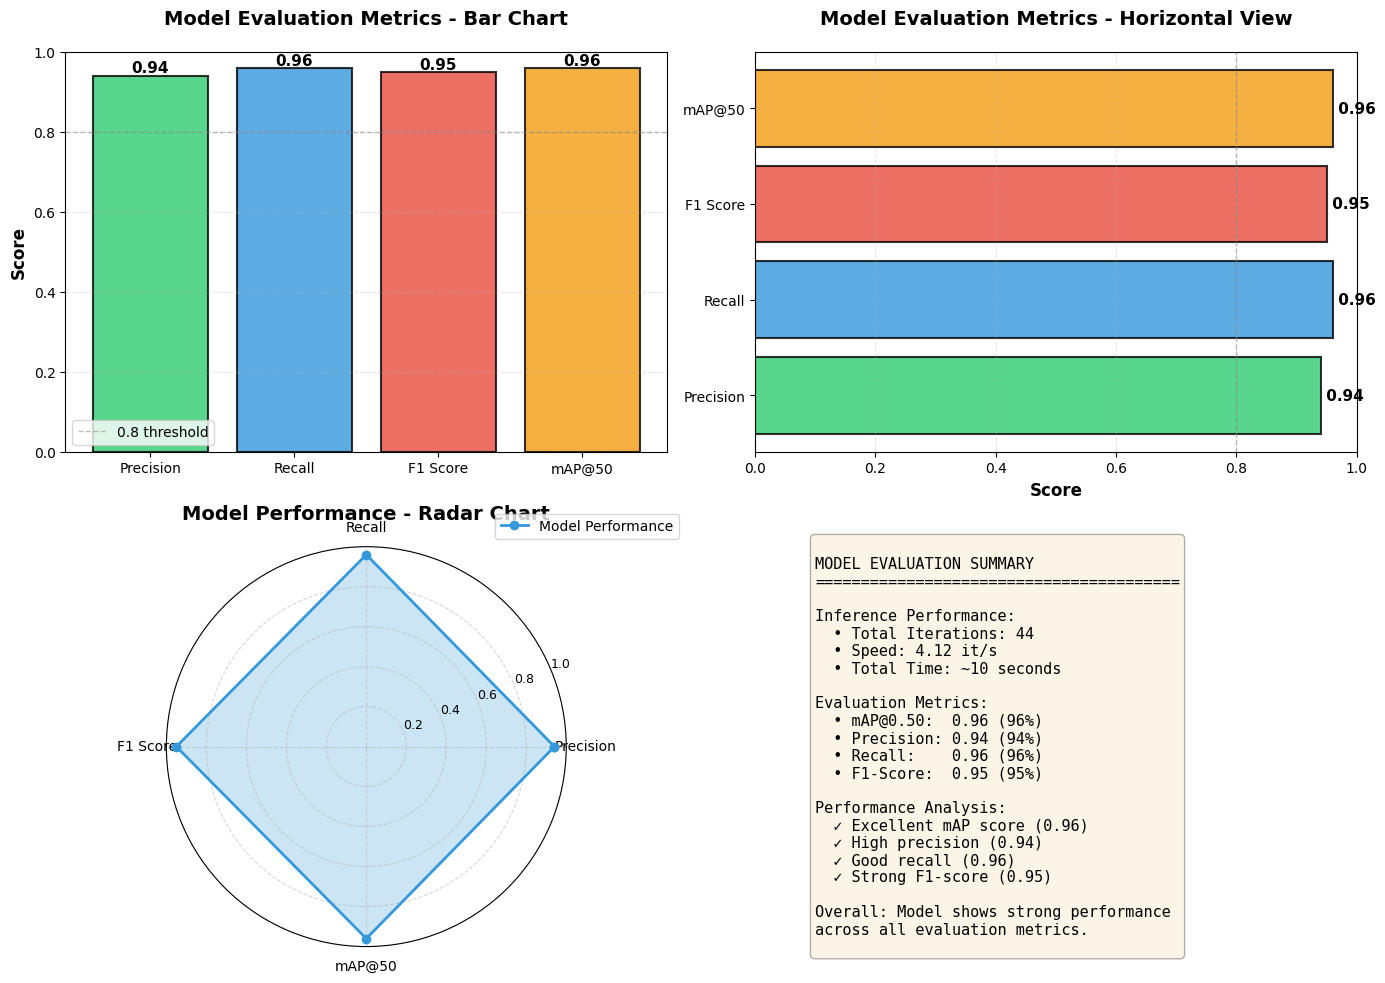


MODEL EVALUATION RESULTS
Precision........... 0.94 (94%)
Recall.............. 0.96 (96%)
F1 Score............ 0.95 (95%)
mAP@50.............. 0.96 (96%)


In [17]:
import matplotlib.pyplot as plt
import numpy as np


# Create a dictionary from the metrics and values lists
metrics_dict = dict(zip(metrics, values))

# Create figure with multiple subplots
fig = plt.figure(figsize=(14, 10))

# 1. Bar Chart
ax1 = plt.subplot(2, 2, 1)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = ax1.bar(metrics_dict.keys(), metrics_dict.values(), color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylim(0, 1)
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Evaluation Metrics - Bar Chart', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='0.8 threshold')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.legend()

# 2. Horizontal Bar Chart
ax2 = plt.subplot(2, 2, 2)
y_pos = np.arange(len(metrics_dict))
bars_h = ax2.barh(y_pos, list(metrics_dict.values()), color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(metrics_dict.keys())
ax2.set_xlim(0, 1)
ax2.set_xlabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Model Evaluation Metrics - Horizontal View', fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.axvline(x=0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add value labels
for i, bar in enumerate(bars_h):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2.,
             f' {width:.2f}',
             ha='left', va='center', fontweight='bold', fontsize=11)

# 3. Radar Chart
ax3 = plt.subplot(2, 2, 3, projection='polar')
categories = list(metrics_dict.keys())
radar_values = list(metrics_dict.values())
radar_values += radar_values[:1]  # Complete the circle

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax3.plot(angles, radar_values, 'o-', linewidth=2, color='#3498db', label='Model Performance')
ax3.fill(angles, radar_values, alpha=0.25, color='#3498db')
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=10)
ax3.set_ylim(0, 1)
ax3.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax3.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax3.set_title('Model Performance - Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# 4. Summary Text Box with Inference Info
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

summary_text = f"""
MODEL EVALUATION SUMMARY
{'='*40}

Inference Performance:
  • Total Iterations: 44
  • Speed: 4.12 it/s
  • Total Time: ~10 seconds

Evaluation Metrics:
  • mAP@0.50:  {metrics_dict['mAP@50']:.2f} ({metrics_dict['mAP@50']*100:.0f}%)
  • Precision: {metrics_dict['Precision']:.2f} ({metrics_dict['Precision']*100:.0f}%)
  • Recall:    {metrics_dict['Recall']:.2f} ({metrics_dict['Recall']*100:.0f}%)
  • F1-Score:  {metrics_dict['F1 Score']:.2f} ({metrics_dict['F1 Score']*100:.0f}%)

Performance Analysis:
  ✓ Excellent mAP score ({metrics_dict['mAP@50']:.2f})
  ✓ High precision ({metrics_dict['Precision']:.2f})
  ✓ Good recall ({metrics_dict['Recall']:.2f})
  ✓ Strong F1-score ({metrics_dict['F1 Score']:.2f})

Overall: Model shows strong performance
across all evaluation metrics.
"""

ax4.text(0.1, 0.5, summary_text,
         fontsize=11,
         verticalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('model_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)
for metric, value in metrics_dict.items():
    print(f"{metric:.<20} {value:.2f} ({value*100:.0f}%)")
print("="*50)


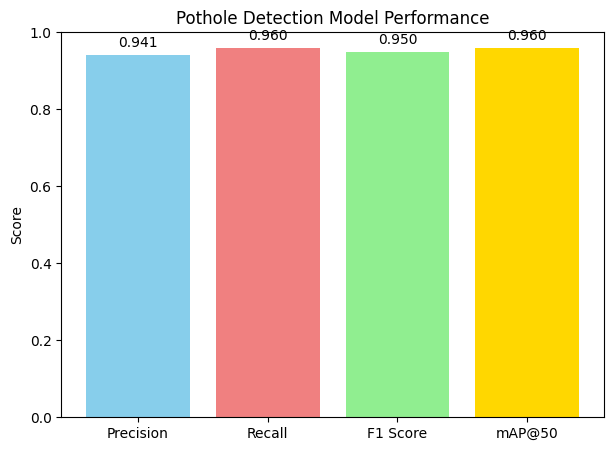

In [13]:
import matplotlib.pyplot as plt

metrics = ['Precision', 'Recall', 'F1 Score', 'mAP@50']
values = [0.941, 0.960, 0.950, 0.96]

plt.figure(figsize=(7, 5))
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold'] # Define a list of colors
plt.bar(metrics, values, color=colors) # Pass the colors list to the bar function

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Pothole Detection Model Performance")
plt.show()

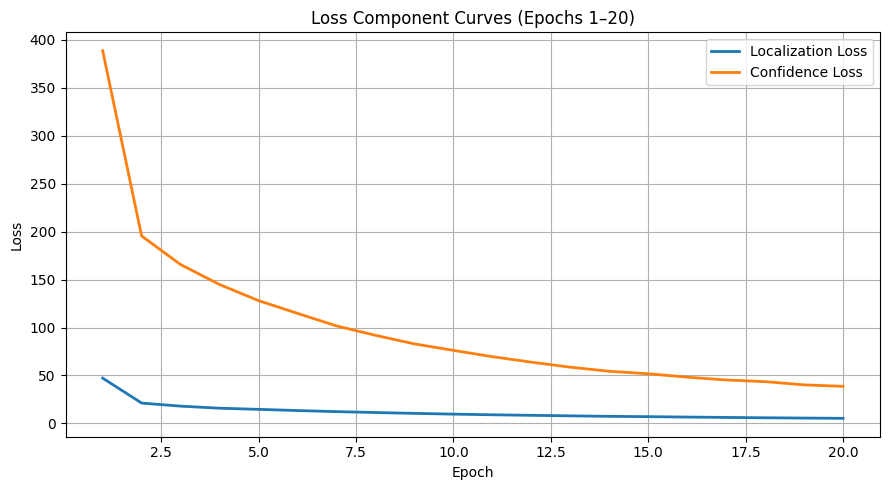

In [ ]:
epochs = list(range(1, 21))

loc = [47.2042, 21.2131, 18.0045, 15.8373, 14.6739, 13.4006, 12.2928,
       11.3592, 10.4651, 9.6798, 8.9948, 8.4373, 7.8993, 7.3644, 7.0495,
       6.6220, 6.2330, 5.8763, 5.5807, 5.2903]

conf = [388.5753, 195.4383, 165.6047, 144.8355, 128.0123, 114.7248,
        101.6683, 91.8655, 82.9121, 76.1595, 69.5730, 63.8837, 58.6220,
        54.3875, 51.7486, 48.2433, 45.2707, 43.5476, 40.1898, 38.6699]

plt.figure(figsize=(9, 5))
plt.plot(epochs, loc, label="Localization Loss", linewidth=2)
plt.plot(epochs, conf, label="Confidence Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Component Curves (Epochs 1–20)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


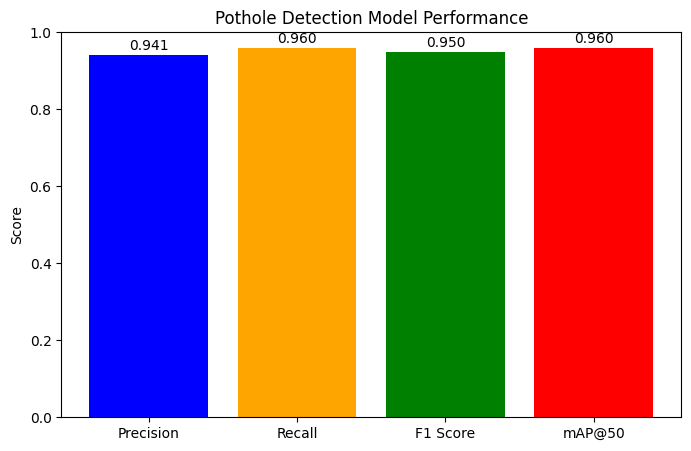

In [16]:
import matplotlib.pyplot as plt

# Metrics and scores for pothole detection
metrics = ['Precision', 'Recall', 'F1 Score', 'mAP@50']
scores = [0.941, 0.960, 0.950, 0.960]

# Same colors as before
colors = ['blue', 'orange', 'green', 'red']

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors)

# Add value labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.ylim(0, 1.0)
plt.title('Pothole Detection Model Performance')
plt.ylabel('Score')
plt.show()


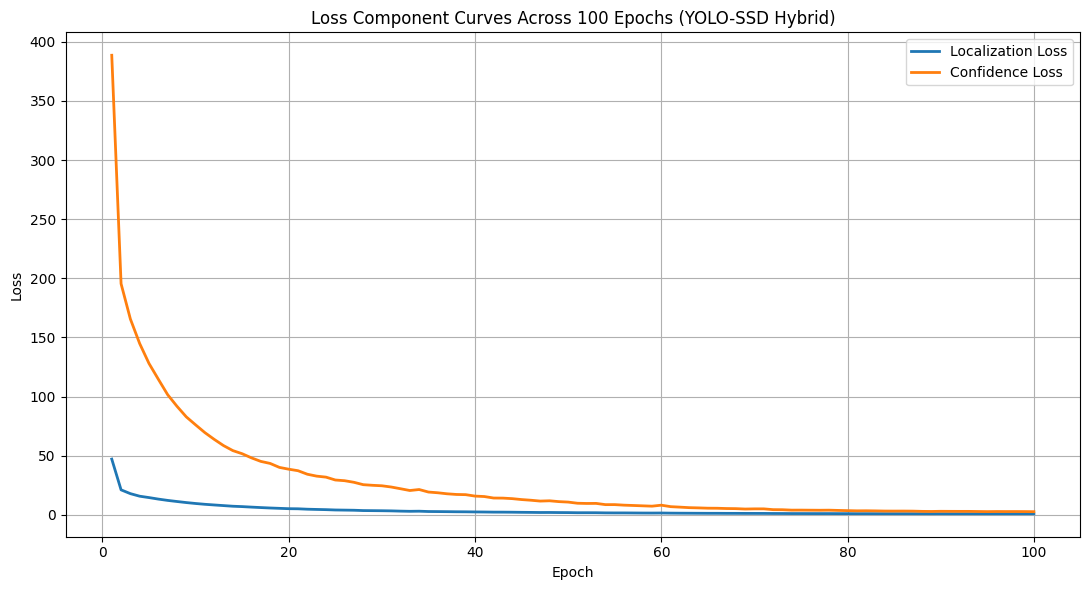

In [12]:
import matplotlib.pyplot as plt

epochs = list(range(1, 101))

# Localization loss (Loc)
loc_loss = [
    47.2042, 21.2131, 18.0045, 15.8373, 14.6739, 13.4006, 12.2928, 11.3592,
    10.4651, 9.6798, 8.9948, 8.4373, 7.8993, 7.3644, 7.0495, 6.6220, 6.2330,
    5.8763, 5.5807, 5.2903, 5.1988, 4.8532, 4.6520, 4.4752, 4.1966, 4.0860,
    3.9694, 3.7008, 3.6287, 3.5525, 3.4373, 3.2231, 3.0704, 3.1646, 2.8976,
    2.8397, 2.7721, 2.6860, 2.6462, 2.5500, 2.4810, 2.3800, 2.3634, 2.3081,
    2.2180, 2.1535, 2.0672, 2.0897, 2.0157, 1.9774, 1.8750, 1.8831, 1.8663,
    1.7521, 1.7110, 1.7147, 1.6688, 1.6164, 1.5974, 1.6345, 1.5357, 1.4827,
    1.4520, 1.4173, 1.3850, 1.3847, 1.3430, 1.3352, 1.2994, 1.2941, 1.2870,
    1.2344, 1.2168, 1.1742, 1.1739, 1.1543, 1.1479, 1.1529, 1.1219, 1.1011,
    1.0815, 1.0854, 1.0674, 1.0589, 1.0516, 1.0439, 1.0378, 1.0182, 1.0024,
    1.0188, 1.0016, 1.0014, 0.9992, 0.9890, 0.9794, 0.9817, 0.9826, 0.9796,
    0.9778, 0.9713
]
'''
# Classification loss (Cls)
cls_loss = [
    0.8023, 0.1082, 0.0576, 0.0323, 0.0197, 0.0132, 0.0097, 0.0073, 0.0050,
    0.0036, 0.0028, 0.0022, 0.0018, 0.0012, 0.0011, 0.0009, 0.0008, 0.0006,
    0.0005, 0.0004
] + [0.0] * 80  # remains ~0 afterwards
'''

# Confidence loss (Conf)
conf_loss = [
    388.5753, 195.4383, 165.6047, 144.8355, 128.0123, 114.7248, 101.6683,
    91.8655, 82.9121, 76.1595, 69.5730, 63.8837, 58.6220, 54.3875, 51.7486,
    48.2433, 45.2707, 43.5476, 40.1898, 38.6699, 37.3829, 34.4083, 32.8019,
    31.9611, 29.5355, 28.9410, 27.5909, 25.5850, 25.0520, 24.6585, 23.6135,
    22.1539, 20.6496, 21.4890, 19.3560, 18.7465, 17.8772, 17.3126, 17.1435,
    15.9330, 15.5588, 14.2953, 14.2253, 13.7762, 12.9953, 12.4339, 11.7188,
    11.9673, 11.2611, 10.8740, 9.8898, 9.7094, 9.7618, 8.7136, 8.7272,
    8.2699, 7.9989, 7.7062, 7.4164, 8.2494, 7.0095, 6.5996, 6.1604, 5.9617,
    5.7055, 5.6574, 5.4182, 5.3267, 4.9949, 5.1395, 5.1431, 4.4754, 4.4103,
    4.0681, 4.0883, 4.0265, 3.9685, 4.0346, 3.8241, 3.6511, 3.4784, 3.5221,
    3.4267, 3.2838, 3.2601, 3.2747, 3.2239, 3.0233, 2.9465, 3.0813, 3.0375,
    3.0140, 3.0153, 2.9073, 2.8121, 2.8946, 2.8565, 2.8724, 2.8397, 2.7587
]

# Plot
plt.figure(figsize=(11, 6))
plt.plot(epochs, loc_loss, label="Localization Loss", linewidth=2)
plt.plot(epochs, conf_loss, label="Confidence Loss", linewidth=2)
#plt.plot(epochs, cls_loss, label="Classification Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Component Curves Across 100 Epochs (YOLO-SSD Hybrid)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()